In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 25.9 MB/s eta 0:00:00


In [ ]:
import os

input_folder = "/content/drive/MyDrive/GOST_Project/общие_фото_новинка"

output_folder = "/content/drive/MyDrive/GOST_Project/ocr_results2"
os.makedirs(output_folder, exist_ok=True)

files = [f for f in os.listdir(input_folder) if f.endswith(('.jpg', '.png'))]
print(f"Найдено {len(files)} картинок")

Найдено 372 картинок


In [ ]:
import easyocr

reader = easyocr.Reader(['ru', 'en'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% Complete

In [ ]:
import json
from PIL import Image

test_file = files[0]
image_path = os.path.join(input_folder, test_file)

print(f"Обработка: {test_file}")

result = reader.readtext(image_path)

print(f"Распознано {len(result)} фрагментов")
print("Первые 3:")
for i, (bbox, text, confidence) in enumerate(result[:3]):
    print(f"  [{i}] Текст: '{text}', координаты: {bbox}, уверенность: {confidence:.2f}")

Обработка: alekseeva_e_a_page_1.png
Распознано 17 фрагментов
Первые 3:
  [0] Текст: 'Правительство Российской Федерации', координаты: [[np.int32(484), np.int32(159)], [np.int32(1285), np.int32(159)], [np.int32(1285), np.int32(221)], [np.int32(484), np.int32(221)]], уверенность: 0.92
  [1] Текст: 'Федеральное государственное автономное образовательное учреждение', координаты: [[np.int32(247), np.int32(257)], [np.int32(1526), np.int32(257)], [np.int32(1526), np.int32(309)], [np.int32(247), np.int32(309)]], уверенность: 0.60
  [2] Текст: 'высшего профессионального образования', координаты: [[np.int32(509), np.int32(302)], [np.int32(1262), np.int32(302)], [np.int32(1262), np.int32(355)], [np.int32(509), np.int32(355)]], уверенность: 0.97


In [ ]:
import numpy as np

for filename in files:
    image_path = os.path.join(input_folder, filename)
    print(f"Обработка: {filename}")

    result = reader.readtext(image_path)

    words_data = []
    for (bbox, text, confidence) in result:
        x_coords = [p[0] for p in bbox]
        y_coords = [p[1] for p in bbox]
        bbox_rect = [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]

        bbox_rect = [int(coord) for coord in bbox_rect]
        confidence = float(confidence)

        words_data.append({
            "text": text,
            "bbox": bbox_rect,
            "confidence": confidence
        })

    output_path = os.path.join(output_folder, filename.replace('.jpg', '.json').replace('.png', '.json'))
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump({
            "image": filename,
            "words": words_data
        }, f, ensure_ascii=False, indent=2)

Обработка: alekseeva_e_a_page_1.png
Обработка: alekseeva_e_a_page_2.png
Обработка: alekseeva_e_a_page_3.png
Обработка: alekseeva_e_a_page_9.png
Обработка: alekseeva_e_a_page_8.png
Обработка: alekseeva_e_a_page_5.png
Обработка: alekseeva_e_a_page_10.png
Обработка: alekseeva_e_a_page_4.png
Обработка: alekseeva_e_a_page_6.png
Обработка: alekseeva_e_a_page_7.png
Обработка: alekseeva_e_a_page_32.png
Обработка: alekseeva_e_a_page_37.png
Обработка: alekseeva_e_a_page_31.png
Обработка: alekseeva_e_a_page_35.png
Обработка: alekseeva_e_a_page_33.png
Обработка: alekseeva_e_a_page_34.png
Обработка: alekseeva_e_a_page_36.png
Обработка: tohtueva_e_a_page_4.png
Обработка: tohtueva_e_a_page_1.png
Обработка: tohtueva_e_a_page_3.png
Обработка: tohtueva_e_a_page_5.png
Обработка: tohtueva_e_a_page_2.png
Обработка: tohtueva_e_a_page_9.png
Обработка: tohtueva_e_a_page_11.png
Обработка: tohtueva_e_a_page_13.png
Обработка: tohtueva_e_a_page_10.png
Обработка: tohtueva_e_a_page_12.png
Обработка: tohtueva_e_a_pa

Загружен файл: Воробьев_ТекстВКР_page_31.json
Картинка: Воробьев_ТекстВКР_page_31.png
Найдено слов: 42

Первые 5 распознанных слов:
  1. 'Image Alignment' → координаты: [602, 225, 829, 264]
  2. 'Dreambooth' → координаты: [550, 262, 680, 288]
  3. 'обучением CLIP' → координаты: [711, 259, 913, 295]
  4. 'Dreambooth' → координаты: [428, 291, 558, 315]
  5. 'без обучения' → координаты: [566, 290, 744, 320]


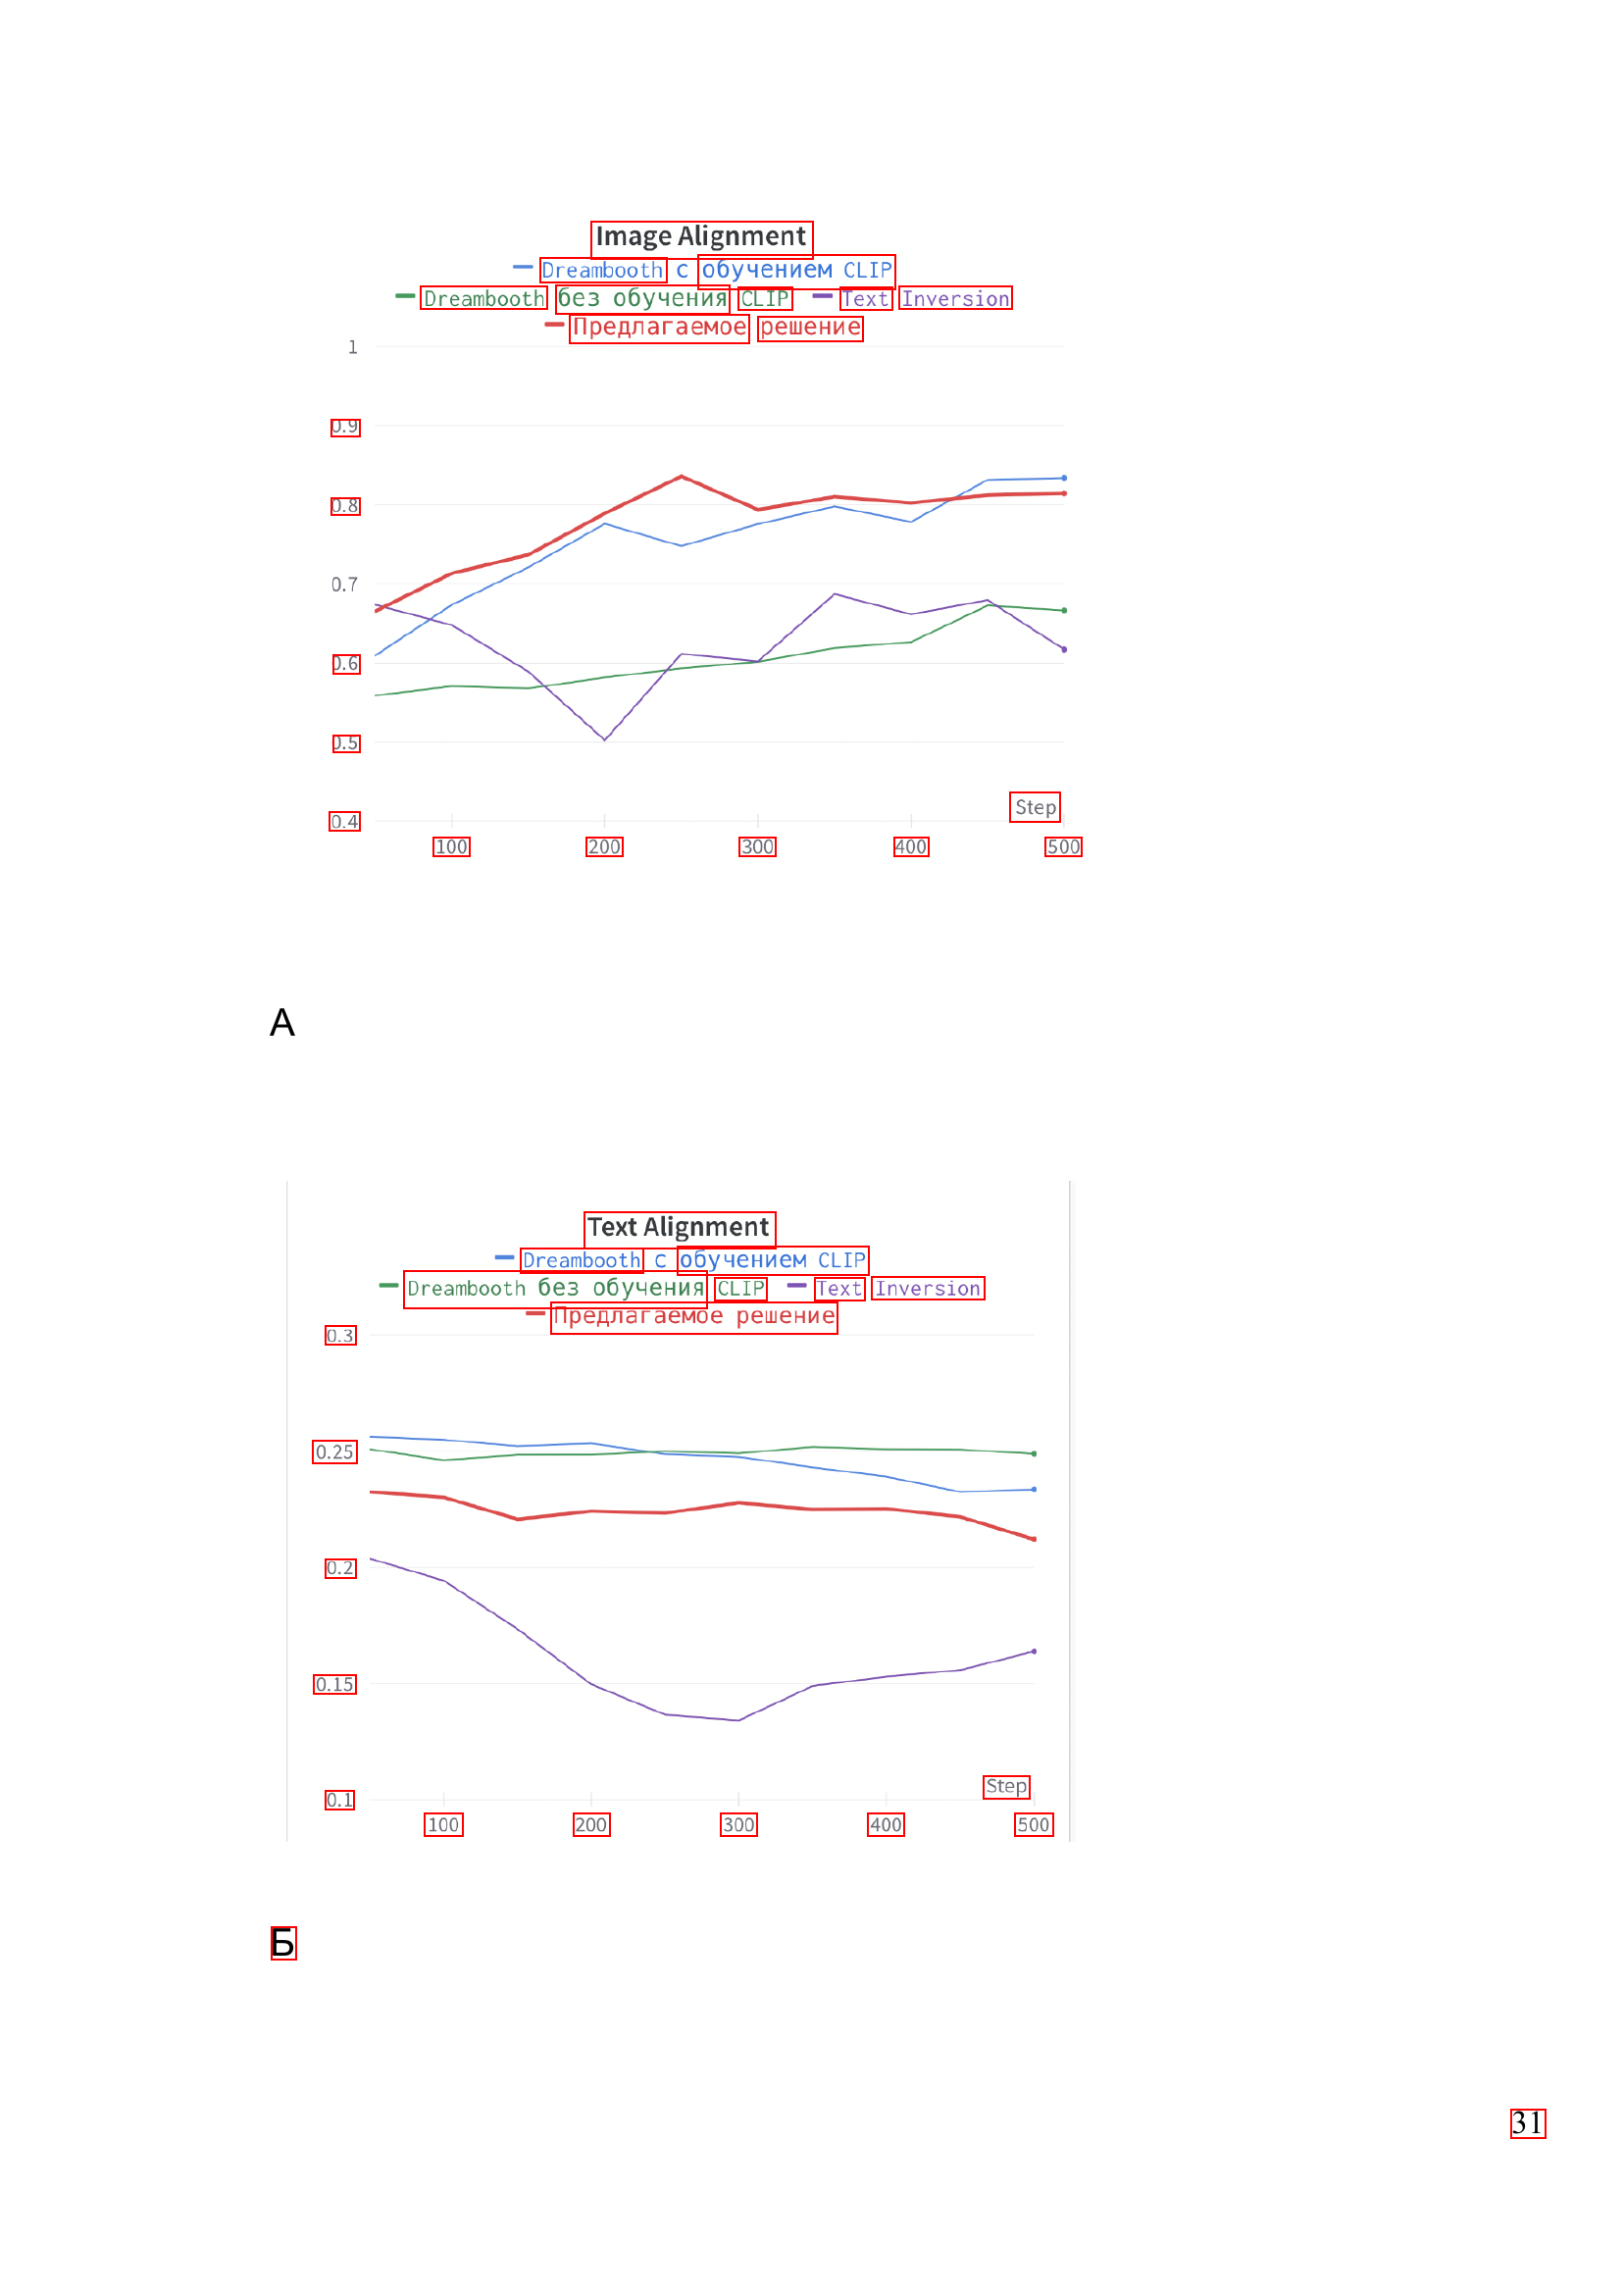

In [2]:
import json
from PIL import Image, ImageDraw
import os
ocr_folder = "/content/drive/MyDrive/GOST_Project/ocr_results2"
pages_folder = "/content/drive/MyDrive/GOST_Project/общие_фото_новинка"

json_file = "Воробьев_ТекстВКР_page_31.json"
json_path = os.path.join(ocr_folder, json_file)

with open(json_path, 'r') as f:
    data = json.load(f)

print(f"Загружен файл: {json_file}")
print(f"Картинка: {data['image']}")
print(f"Найдено слов: {len(data['words'])}")
print("\nПервые 5 распознанных слов:")
for i, word in enumerate(data['words'][:5]):
    print(f"  {i+1}. '{word['text']}' → координаты: {word['bbox']}")

image_path = os.path.join(pages_folder, data['image'])
image = Image.open(image_path)
draw = ImageDraw.Draw(image)

for word in data['words']:
    bbox = word['bbox']
    draw.rectangle(bbox, outline='red', width=2)

image